In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import boto3
import icechunk
import xarray as xr

from saidownscale import catalog

In [3]:
def open_icechunk(path):
    bucket, prefix = path.replace("s3://", "").split("/", 1)
    storage = icechunk.s3_storage(bucket=bucket, prefix=prefix)
    repo = icechunk.Repository.open(storage)
    session = repo.readonly_session("main")

    ds = xr.open_dataset(session.store, engine="zarr", chunks={})
    return ds

In [4]:
def get_fname(var, scenario, version="test015_benchmark", ens="007"):
    fname = (
        "s3://carbonplan-scratch/srm/output/qa/"
        + version
        + "/"
        + scenario
        + "/CESM2-WACCM/"
        + var
        + "/"
        + ens
        + "/lat-35.0to-22.0_lon16.0to33.0/*/*/"
        + scenario
        + ".icechunk/"
    )

    return fname

In [5]:
def resolve_s3_glob(path):
    """Resolve a single * wildcard in an S3 path to a real path."""
    bucket, prefix = path.replace("s3://", "").split("/", 1)

    before, after = prefix.split("*/", 1)

    s3 = boto3.client("s3")
    response = s3.list_objects_v2(Bucket=bucket, Prefix=before, Delimiter="/")

    matches = [f"s3://{bucket}/{cp['Prefix']}{after}" for cp in response.get("CommonPrefixes", [])]

    if not matches:
        raise ValueError(f"No S3 paths matched: {path}")
    if len(matches) > 1:
        raise ValueError(f"Multiple matches: {matches}")

    return matches[0]

In [6]:
var = "tasmax"
sample_day = "2070-01-01"
ensemble_member = "001"

In [7]:
coarse = (
    (
        catalog.get("CESM2-WACCM-G6-1.5K-icechunk")
        .to_xarray()
        .sel(ensemble_member=ensemble_member)
        .sel(lon=slice(16, 33), lat=slice(-35, -22))
    )
    .sel(time=sample_day)[var]
    .load()
)

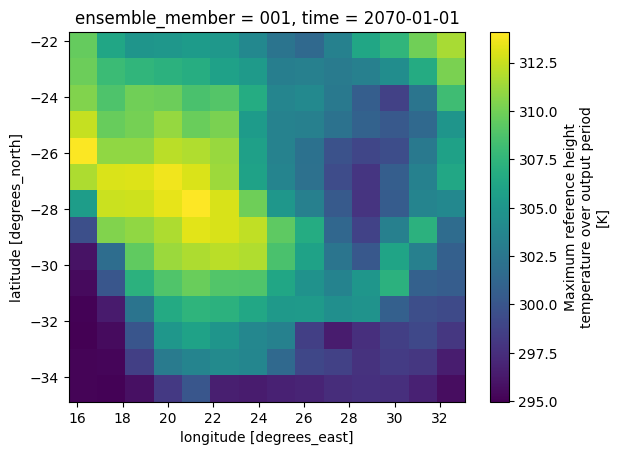

In [8]:
coarse.plot()

In [9]:
fname = get_fname(var=var, version="v2026.06.17", scenario="g6-1.5k", ens=ensemble_member)
fname = resolve_s3_glob(fname)
fname = resolve_s3_glob(fname)
downscaled = open_icechunk(path=fname).sel(time=sample_day)[[var]].load()

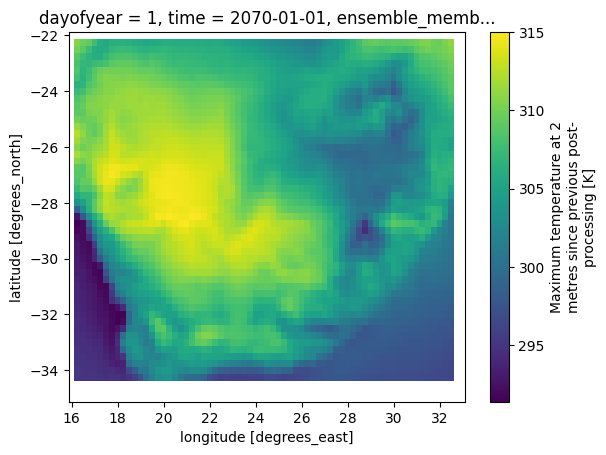

In [10]:
downscaled[var].plot()

In [11]:
coarse.drop_encoding().to_zarr(
    "s3://carbonplan-srm/output/explainer/figures/figure1_coarse.zarr", mode="w"
)
downscaled.drop_encoding().to_zarr(
    "s3://carbonplan-srm/output/explainer/figures/figure1_downscaled.zarr", mode="w"
)

/opt/coiled/env/lib/python3.13/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=3, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/opt/coiled/env/lib/python3.13/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificat